In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from tqdm import tqdm

plt.style.use("default")

In [2]:
import os

print(os.listdir("../Data"))

['BraTS2020_TrainingData', 'BraTS2020_ValidationData']


In [3]:
from pathlib import Path

DATASET_DIR = r"../Data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

dataset_path = Path(DATASET_DIR)


patient_folders = sorted([
    p for p in dataset_path.iterdir()
    if p.is_dir()
])

print("Number of Patients:", len(patient_folders))

for p in patient_folders[:5]:
    print(p.name)

Number of Patients: 369
BraTS20_Training_001
BraTS20_Training_002
BraTS20_Training_003
BraTS20_Training_004
BraTS20_Training_005


In [4]:
import nibabel as nib

def load_patient(patient_dir):

    flair = list(patient_dir.glob("*flair.nii*"))[0]
    t1    = list(patient_dir.glob("*t1.nii*"))[0]
    t1ce  = list(patient_dir.glob("*t1ce.nii*"))[0]
    t2    = list(patient_dir.glob("*t2.nii*"))[0]

    seg_candidates = (
        list(patient_dir.glob("*seg*.nii*"))
        + list(patient_dir.glob("*Seg*.nii*"))
        + list(patient_dir.glob("*Segm*.nii*"))
    )

    if len(seg_candidates) == 0:
        raise FileNotFoundError(
            f"No segmentation file found in {patient_dir}"
        )

    seg = seg_candidates[0]

    return {
        "flair": nib.load(flair).get_fdata(),
        "t1": nib.load(t1).get_fdata(),
        "t1ce": nib.load(t1ce).get_fdata(),
        "t2": nib.load(t2).get_fdata(),
        "seg": nib.load(seg).get_fdata()
    }

In [5]:
sample_patient = patient_folders[0]

data = load_patient(sample_patient)

for key, value in data.items():
    print(key, value.shape)

flair (240, 240, 155)
t1 (240, 240, 155)
t1ce (240, 240, 155)
t2 (240, 240, 155)
seg (240, 240, 155)


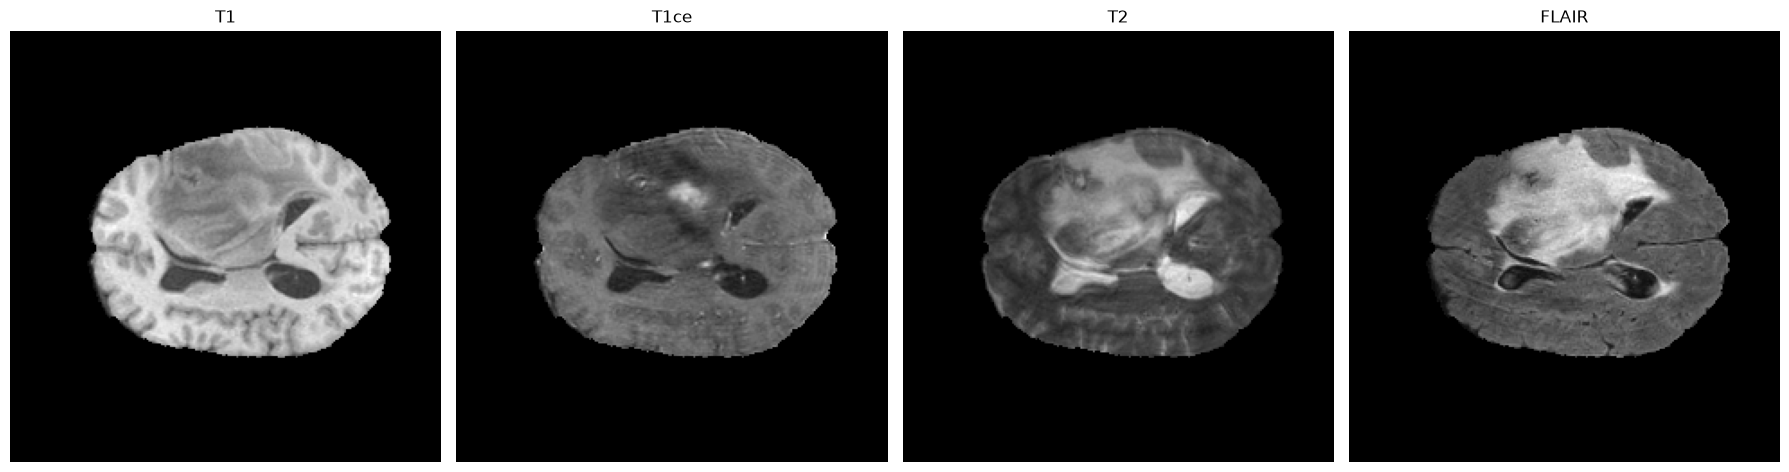

In [6]:
slice_idx = 80

fig, ax = plt.subplots(
    1,
    4,
    figsize=(18,5)
)

ax[0].imshow(
    data["t1"][:,:,slice_idx],
    cmap="gray"
)
ax[0].set_title("T1")

ax[1].imshow(
    data["t1ce"][:,:,slice_idx],
    cmap="gray"
)
ax[1].set_title("T1ce")

ax[2].imshow(
    data["t2"][:,:,slice_idx],
    cmap="gray"
)
ax[2].set_title("T2")

ax[3].imshow(
    data["flair"][:,:,slice_idx],
    cmap="gray"
)
ax[3].set_title("FLAIR")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

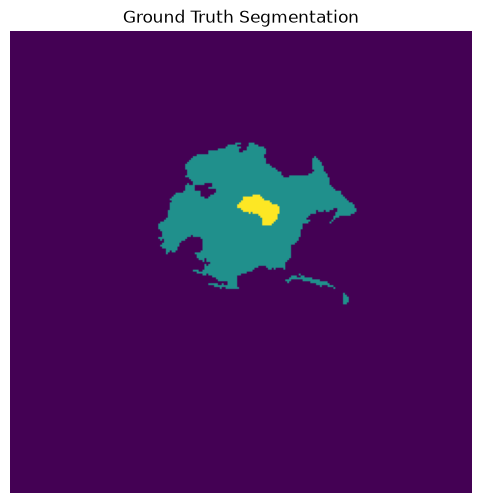

In [7]:
#segmentation visualization

plt.figure(figsize=(6,6))

plt.imshow(
    data["seg"][:,:,slice_idx]
)

plt.title("Ground Truth Segmentation")
plt.axis("off")

plt.show()

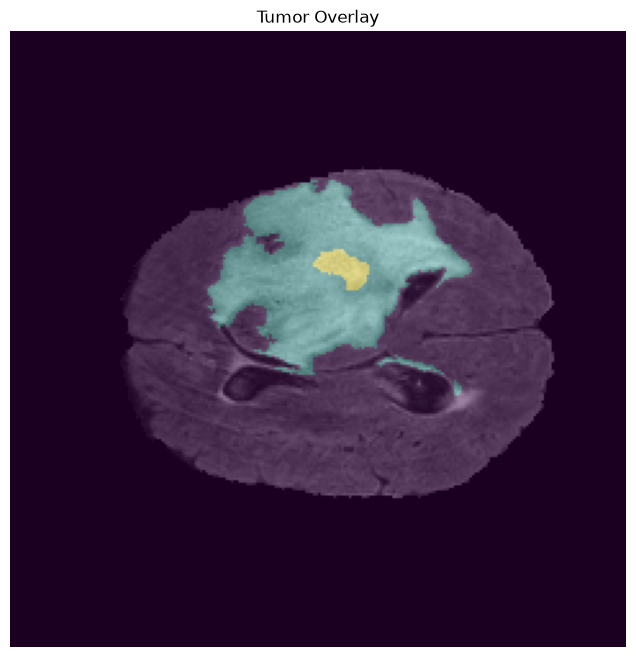

In [8]:
plt.figure(figsize=(8,8))

plt.imshow(
    data["flair"][:,:,slice_idx],
    cmap="gray"
)

plt.imshow(
    data["seg"][:,:,slice_idx],
    alpha=0.4
)

plt.title("Tumor Overlay")
plt.axis("off")

plt.show()

In [9]:
labels = np.unique(data["seg"])

print("Labels Found:", labels)

Labels Found: [0. 1. 2. 4.]


In [10]:
seg = data["seg"]

unique, counts = np.unique(
    seg,
    return_counts=True
)

for u, c in zip(unique, counts):
    print(
        f"Label {int(u)} : {c:,}"
    )

Label 0 : 8,716,021
Label 1 : 15,443
Label 2 : 168,794
Label 4 : 27,742


In [11]:
patient = patient_folders[354]

print(patient)

for f in patient.iterdir():
    print(f.name)

..\Data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_355
BraTS20_Training_355_flair.nii
BraTS20_Training_355_t1.nii
BraTS20_Training_355_t1ce.nii
BraTS20_Training_355_t2.nii
W39_1998.09.19_Segm.nii


In [12]:
from tqdm import tqdm

bad_patients = []

for patient in tqdm(patient_folders):

    files = [f.name for f in patient.iterdir()]

    required = [
        "_flair.nii",
        "_t1.nii",
        "_t1ce.nii",
        "_t2.nii",
        "_seg.nii"
    ]

    for req in required:

        if not any(req in f for f in files):

            bad_patients.append(
                (patient.name, req)
            )

print("\nBad Patients:")
print(bad_patients)

100%|██████████| 369/369 [00:00<00:00, 10249.18it/s]


Bad Patients:
[('BraTS20_Training_355', '_seg.nii')]


In [13]:
shapes = []

for patient in tqdm(patient_folders):

    patient_data = load_patient(patient)

    shapes.append(
        patient_data["flair"].shape
    )

unique_shapes = set(shapes)

print(unique_shapes)

100%|██████████| 369/369 [03:31<00:00,  1.74it/s]

{(240, 240, 155)}


In [14]:
label_counts = {
    0:0,
    1:0,
    2:0,
    4:0
}

for patient in tqdm(patient_folders):

    seg = load_patient(patient)["seg"]

    unique, counts = np.unique(
        seg,
        return_counts=True
    )

    for u,c in zip(unique, counts):
        label_counts[int(u)] += int(c)

label_counts

100%|██████████| 369/369 [03:40<00:00,  1.67it/s]


{0: 3257699276, 1: 8161996, 2: 21302318, 4: 7268410}

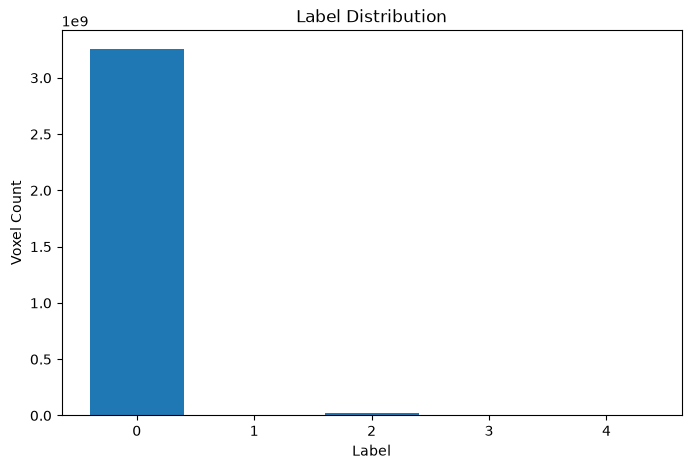

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    list(label_counts.keys()),
    list(label_counts.values())
)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Voxel Count")

plt.show()

In [16]:
tumor_volumes = []

for patient in tqdm(patient_folders):

    seg = load_patient(patient)["seg"]

    volume = np.sum(seg > 0)

    tumor_volumes.append(volume)

tumor_volumes = np.array(tumor_volumes)

print("Mean :", tumor_volumes.mean())
print("Std  :", tumor_volumes.std())
print("Min  :", tumor_volumes.min())
print("Max  :", tumor_volumes.max())

100%|██████████| 369/369 [02:16<00:00,  2.70it/s]

Mean : 99546.67750677507
Std  : 59348.56129060385
Min  : 7285
Max  : 361783


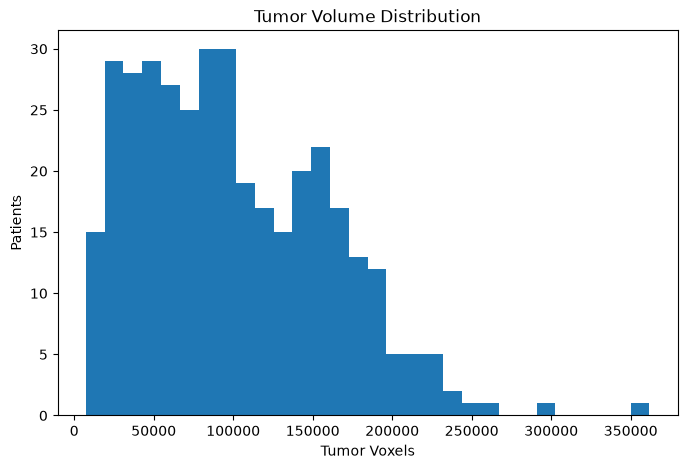

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    tumor_volumes,
    bins=30
)

plt.title(
    "Tumor Volume Distribution"
)

plt.xlabel("Tumor Voxels")
plt.ylabel("Patients")

plt.show()

In [18]:
modalities = [
    "t1",
    "t1ce",
    "t2",
    "flair"
]

stats = []

for patient in tqdm(patient_folders):

    patient_data = load_patient(patient)

    for mod in modalities:

        img = patient_data[mod]

        brain = img[img > 0]

        stats.append([
            mod,
            brain.mean(),
            brain.std(),
            brain.min(),
            brain.max()
        ])

df = pd.DataFrame(
    stats,
    columns=[
        "Modality",
        "Mean",
        "Std",
        "Min",
        "Max"
    ]
)

df.head()

100%|██████████| 369/369 [06:18<00:00,  1.02s/it]


,Modality,Mean,Std,Min,Max
0,t1,354.272719,84.187028,25.0,678.0
1,t1ce,417.329238,109.193003,49.0,1845.0
2,t2,114.693977,47.691027,5.0,376.0
3,flair,173.003396,64.865939,14.0,625.0
4,t1,411.141513,99.469818,17.0,757.0


In [19]:
df.groupby(
    "Modality"
).mean()

,Mean,Std,Min,Max
Modality,,,,
flair,460.413444,140.174776,7.340859,1457.151946
t1,675.102248,174.987367,28.713116,1781.048541
t1ce,788.310680,215.514631,36.607076,3088.357067
t2,769.847344,293.730856,7.290857,2549.583687


In [20]:
os.makedirs(
    "outputs",
    exist_ok=True
)

plt.figure(figsize=(8,5))

plt.hist(
    tumor_volumes,
    bins=30
)

plt.title(
    "Tumor Volume Distribution"
)

plt.savefig(
    "outputs/tumor_volume_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [13]:
from train_gcn import train_gcn

model = train_gcn(
    train_loader,
    val_loader,
    epochs=200,
    lr=5e-4
)

ModuleNotFoundError: No module named 'train_gcn'